In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1) Carga de ambos datasets:

# 1.1) Carga de metadatos de las canciones (Music Info):
df_music = pd.read_csv('../data/raw/Music Info.csv')

# 1.2) Carga optimizada del historial de escuchas (Listening History): 
dtype_dict = {
    'track_id': 'category',
    'user_id': 'category',
    'playcount': 'uint16' 
}
df_history = pd.read_csv('../data/raw/User Listening History.csv', dtype=dtype_dict)

df_history.head(3)

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


El dataset de music no será util para el EDA pero le echamos un vistazo por si lo usamos más adelante

In [12]:
print(f"El tamaño del dataset de music info es: {df_music.shape}")
print(f"El número de nulos por feature en music info es:\n{df_music.isnull().sum()}")

print("")
print(f"El tamaño del dataset de users es:\n{df_history.shape}")
print(f"El número de nulos por feature en users es: {df_history.isnull().sum()}")


El tamaño del dataset de music info es: (50683, 21)
El número de nulos por feature en music info es:
track_id                   0
name                       0
artist                     0
spotify_preview_url        0
spotify_id                 0
tags                    1127
genre                  28335
year                       0
duration_ms                0
danceability               0
energy                     0
key                        0
loudness                   0
mode                       0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0
tempo                      0
time_signature             0
dtype: int64

El tamaño del dataset de users es:
(9711301, 3)
El número de nulos por feature en users es: track_id     0
user_id      0
playcount    0
dtype: int64


Nos centramos en el dataset util y realizamos una exploracion a fondo

In [15]:
user_uniq = df_history["user_id"].nunique()
cancion_uniq = df_history["track_id"].nunique()

print(f"Users únicos {user_uniq}")
print(f"Canciones únicas {cancion_uniq}")

print(f"Desde esos datos vemos que la densidad de la matriz es: {df_history.shape[0]/(user_uniq *cancion_uniq):.4%}")

Users únicos 962037
Canciones únicas 30459
Desde esos datos vemos que la densidad de la matriz es: 0.0331%


Podemos apreciar una densidad bajísima, esto es muy común en estos tipos de problemas, 962,037 usuarios vs. 30,459 canciones. Eso es ~32 usuarios por canción. Es un dataset "alto y estrecho"


In [24]:
interaccion_user = df_history["user_id"].value_counts()
print(interaccion_user.describe(),"\n")
print(interaccion_user.quantile([0.9,0.95,0.99]))

count    962037.000000
mean         10.094519
std          14.555314
min           1.000000
25%           3.000000
50%           5.000000
75%          11.000000
max         784.000000
Name: count, dtype: float64 

0.90    24.0
0.95    35.0
0.99    71.0
Name: count, dtype: float64


Podemos apreciar que la grandísima mayoria de los usuarios (50%) no han escuchado mas de 5 canciones, para evitar tratar con matrices gigantescas y que el entrenamiento sea eterno (o imposible con nuestra memoria) vamos a cortar los users que menos escuchan

---
Vamos a ver usuarios con valores de k bajos para eliminarlos si fuera necesario

In [48]:
for k in [3, 5, 10, 20, 50]:
    pct = (interaccion_user < k).mean() * 100
    print(f"% Users con < {k} interacciones: {pct:.1f}%")
print(f"El user con mas interacciones tiene {max(interaccion_user)}")

k = 5
usuarios_descartados = interaccion_user[interaccion_user < k]
usuarios_conservados = interaccion_user[interaccion_user >= k]

% Users con < 3 interacciones: 24.1%
% Users con < 5 interacciones: 44.4%
% Users con < 10 interacciones: 69.8%
% Users con < 20 interacciones: 86.8%
% Users con < 50 interacciones: 97.5%
El user con mas interacciones tiene 784


Queda asi de forma más clara como la mayoría de los users no aportan un valor útil al modelo y es mejor cortarlos, también se aprecia como un 1% de los users tienen una grandisima cantidad de valoraciones, no solo eso sino que el user con más valoraciones tiene 784.

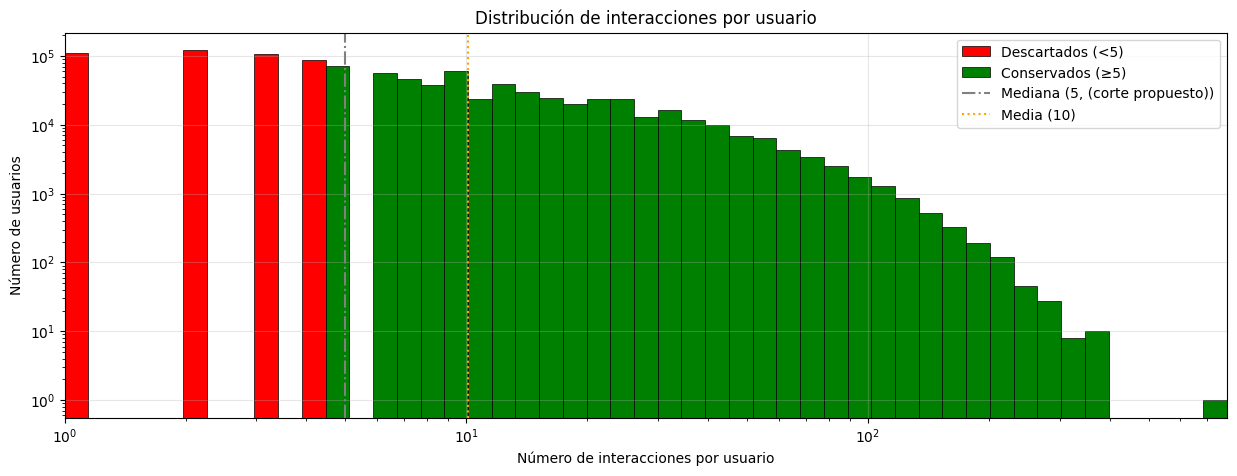

In [58]:
bins = np.logspace(0, np.log10(interaccion_user.max()), 50)


plt.figure(figsize=(15, 5))
plt.hist(usuarios_descartados, bins=bins, color='red', edgecolor='black', linewidth=0.5, label='Descartados (<5)')
plt.hist(usuarios_conservados, bins=bins, color='green', edgecolor='black', linewidth=0.5, label='Conservados (≥5)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1, interaccion_user.max())

plt.axvline(interaccion_user.median(), color='gray', linestyle='-.', label=f'Mediana ({interaccion_user.median():.0f}, (corte propuesto))')
plt.axvline(interaccion_user.mean(), color='orange', linestyle=':', label=f'Media ({interaccion_user.mean():.0f})')

plt.xlabel("Número de interacciones por usuario")
plt.ylabel("Número de usuarios")
plt.title("Distribución de interacciones por usuario")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

--- 
Ahora hacemos lo mismo que con interacciones pero con track_id

In [68]:
interaccion_track = df_history["track_id"].value_counts()
print(interaccion_track.describe(),"\n")
print(interaccion_track.quantile([0.9,0.95,0.99]))

count    30459.000000
mean       318.831905
std       1105.034895
min          1.000000
25%         13.000000
50%         57.000000
75%        255.000000
max      80656.000000
Name: count, dtype: float64 

0.90     738.00
0.95    1378.10
0.99    3835.94
Name: count, dtype: float64


In [71]:
for k in [2, 13, 57, 255, 738]:
    track_pct = (interaccion_track < k).mean() * 100
    print(f"% Tracks con < {k} interacciones: {track_pct:.1f}%")
print(f"El user con mas interacciones tiene {max(interaccion_track)}")

k = 10 # Eliminamos las canciones de "nicho" sin escuchas suficientes
track_descartadas = interaccion_track[interaccion_track < k]
tracks_conservadas = interaccion_track[interaccion_track >= k]

% Tracks con < 2 interacciones: 3.3%
% Tracks con < 13 interacciones: 24.3%
% Tracks con < 57 interacciones: 50.0%
% Tracks con < 255 interacciones: 74.9%
% Tracks con < 738 interacciones: 90.0%
El user con mas interacciones tiene 80656


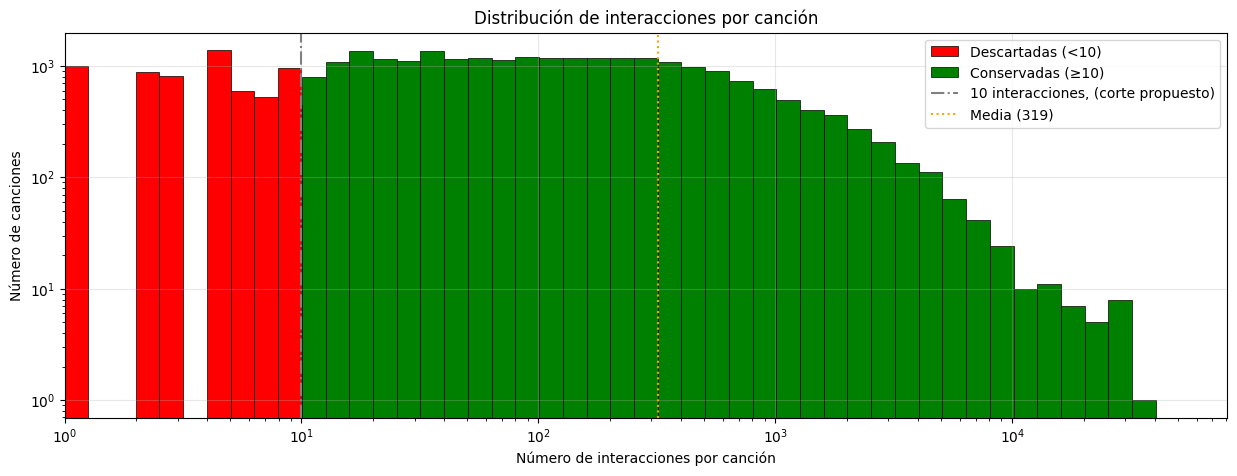

In [74]:
bins_track = np.logspace(0, np.log10(interaccion_track.max()), 50)
bins_track = np.sort(np.unique(np.concatenate([bins_track, [10]]))) # Forzamos para un corte limpio


plt.figure(figsize=(15, 5))
plt.hist(track_descartadas, bins=bins_track, color='red', edgecolor='black', linewidth=0.5, label='Descartadas (<10)')
plt.hist(tracks_conservadas, bins=bins_track, color='green', edgecolor='black', linewidth=0.5, label='Conservadas (≥10)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1, interaccion_track.max())

plt.axvline(10, color='gray', linestyle='-.', label=f'10 interacciones, (corte propuesto)')
plt.axvline(interaccion_track.mean(), color='orange', linestyle=':', label=f'Media ({interaccion_track.mean():.0f})')

plt.xlabel("Número de interacciones por canción")
plt.ylabel("Número de canciones")
plt.title("Distribución de interacciones por canción")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
Por último estudiamos el playcount

In [77]:
playcount = df_history["playcount"]
print(playcount.describe(),"\n")
print(playcount.quantile([0.9,0.95,0.99]))

count    9.711301e+06
mean     2.630946e+00
std      5.706324e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      2.948000e+03
Name: playcount, dtype: float64 

0.90     5.0
0.95     8.0
0.99    21.0
Name: playcount, dtype: float64


La mayoría de las interacciones son "escuché esto una vez".
Una minoría son "lo escuché un par de veces".
Una minoría minúscula tiene playcount altísimo (fans de una canción concreta).

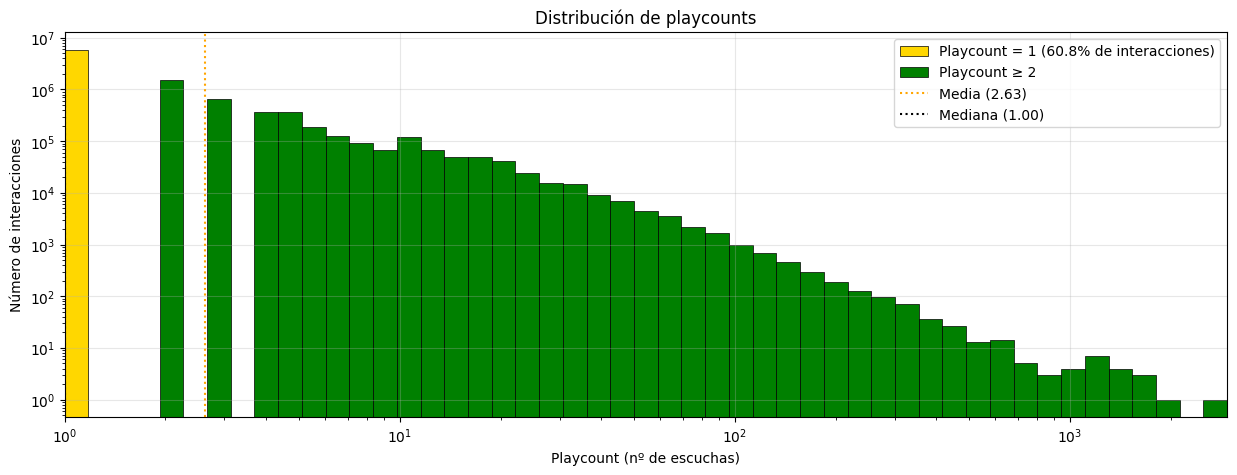

In [92]:
bins_pc = np.logspace(0, np.log10(playcount.max()), 50)
pct_uno = (df_history["playcount"] == 1).mean() * 100

plt.figure(figsize=(15, 5))
plt.hist(df_history["playcount"][df_history["playcount"] <= 1], bins=bins_pc, color='gold', edgecolor='black', linewidth=0.5, label=f'Playcount = 1 ({pct_uno:.1f}% de interacciones)')
plt.hist(df_history["playcount"][df_history["playcount"] > 1], bins=bins_pc, color='green', edgecolor='black', linewidth=0.5, label='Playcount ≥ 2')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1, playcount.max())

plt.axvline(playcount.mean(), color='orange', linestyle=':', label=f'Media ({playcount.mean():.2f})')
plt.axvline(playcount.median(), color='black', linestyle=':', label=f'Mediana ({playcount.median():.2f})')

plt.xlabel("Playcount (nº de escuchas)")
plt.ylabel("Número de interacciones")
plt.title("Distribución de playcounts")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

Debido al gradisimo rando de valores aplicamos log1p con un clippeo debido a la grandisima cola en el percentil 99 y aplicamos un rating sintetico donde a mayor playcount suponemos que mas "estrellas" le daria a la canción donde 3 estrellas es he escuchado la canción solo una vez y 5 es he escuchado la canción muchas veces.

In [116]:
# Con clipping p99 (Escala 3 a 5) 
log_pc_99 = np.log1p(playcount).clip(upper=np.log1p(playcount).quantile(0.99))
log_min_99 = log_pc_99.min()
log_max_99 = log_pc_99.max()

print("Con clipping p99 (Rango 3.0 - 5.0)")
for r in np.arange(3,5.1,0.5):
    log_pc_equiv = log_min_99 + (r - 3) * (log_max_99 - log_min_99) / 2
    pc = np.exp(log_pc_equiv) - 1
    print(f"  Rating {r} -> playcount ~= {pc:.1f}")

# Con clipping p95 (Escala 3 a 5) 
log_pc_95 = np.log1p(playcount).clip(upper=np.log1p(playcount).quantile(0.95))
log_min_95 = log_pc_95.min()
log_max_95 = log_pc_95.max()

print("\nCon clipping p95 (Rango 3.0 - 5.0)")
for r in np.arange(3,5.1,0.5):
    log_pc_equiv = log_min_95 + (r - 3) * (log_max_95 - log_min_95) / 2
    pc = np.exp(log_pc_equiv) - 1
    print(f"  Rating {r} -> playcount ~= {pc:.1f}")

Con clipping p99 (Rango 3.0 - 5.0)
  Rating 3.0 -> playcount ~= 1.0
  Rating 3.5 -> playcount ~= 2.6
  Rating 4.0 -> playcount ~= 5.6
  Rating 4.5 -> playcount ~= 11.1
  Rating 5.0 -> playcount ~= 21.0

Con clipping p95 (Rango 3.0 - 5.0)
  Rating 3.0 -> playcount ~= 1.0
  Rating 3.5 -> playcount ~= 1.9
  Rating 4.0 -> playcount ~= 3.2
  Rating 4.5 -> playcount ~= 5.2
  Rating 5.0 -> playcount ~= 8.0


Nos quedamos con el clipping en percentil 99

---
### Decisiones Finales
Nos quedamos con todos los users que hayan interactuado por lo menos 5 veces, las canciones que hay tenido por lo menos 10 interacciones y ajustamos el playcount en el 99 percentil representandolo como estrellas de 1 a 5

In [ ]:
min_user = 5
min_track = 10

df_filtered = df_history.copy()
original = len(df_filtered)
print(f"Tamaño original: {original}")

while True:
    start_len = len(df_filtered)
    
    track_counts = df_filtered['track_id'].value_counts()
    valid_tracks = track_counts[track_counts >= min_track].index
    df_filtered = df_filtered[df_filtered['track_id'].isin(valid_tracks)]
    
    user_counts = df_filtered['user_id'].value_counts()
    valid_users = user_counts[user_counts >= min_user].index
    df_filtered = df_filtered[df_filtered['user_id'].isin(valid_users)]
    
    end_len = len(df_filtered)
    
    if start_len == end_len:
        break

print(f"Tamaño post-filtrado iterativo: {len(df_filtered)}")
print(f"Se ha hecho una reduccion de {(1-(len(df_filtered)/original))*100:.3f}%")

Tamaño original: 9711301
Tamaño post-filtrado iterativo: 8650751
Se ha hecho una reduccion de 10.921%


In [117]:
df_filtered['target_implicit_confidence'] = np.log1p(df_filtered['playcount']).clip(upper=np.log1p(df_filtered['playcount']).quantile(0.99))

df_filtered['target_bernoulli'] = 1.0

log_pc_clip = df_filtered['target_implicit_confidence']
log_min = log_pc_clip.min()
log_max = log_pc_clip.max()
ratings_continuous = 3 + 2 * (log_pc_clip - log_min) / (log_max - log_min)
df_filtered['target_stars_3_5'] = np.round(ratings_continuous * 2) / 2

print(df_filtered[['user_id', 'track_id', 'playcount', 'target_implicit_confidence', 'target_bernoulli', 'target_stars_3_5']].head())

                                    user_id            track_id  playcount  \
0  b80344d063b5ccb3212f76538f3d9e43d87dca9e  TRIRLYL128F42539D1          1   
1  b80344d063b5ccb3212f76538f3d9e43d87dca9e  TRFUPBA128F934F7E1          1   
2  b80344d063b5ccb3212f76538f3d9e43d87dca9e  TRLQPQJ128F42AA94F          1   
3  b80344d063b5ccb3212f76538f3d9e43d87dca9e  TRTUCUY128F92E1D24          1   
4  b80344d063b5ccb3212f76538f3d9e43d87dca9e  TRHDDQG12903CB53EE          1   

   target_implicit_confidence  target_bernoulli  target_stars_3_5  
0                    0.693147               1.0               3.0  
1                    0.693147               1.0               3.0  
2                    0.693147               1.0               3.0  
3                    0.693147               1.0               3.0  
4                    0.693147               1.0               3.0  
